# Healthcare Premium Prediction

## 1. Introduction & Problem Statement
This notebook aims to predict the annual healthcare premium amount for customers based on their demographics, health history, and other relevant features.
We will explore the data, clean it, perform exploratory data analysis (EDA), engineer new features, and finally build and evaluate machine learning models (Linear Regression, Ridge, XGBoost) to predict the premium amount.

---
## 2. Data Loading & Overview
In this section, we load the dataset and take a quick look at its shape, columns, and a few sample rows to understand the data we are working with.

In [63]:
# Import necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (train_test_split,
                                     RandomizedSearchCV)
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor

# Load the dataset from an Excel file
df = pd.read_excel('datasets/premiums.xlsx')
# Display the first 5 rows of the dataset
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [64]:
# Check the number of rows and columns in the dataset
df.shape

(50000, 13)

## 3. Data Cleaning & Preprocessing
Here we will clean our dataset. This involves:
- Standardizing column names
- Handling missing values
- Removing duplicates
- Correcting erroneous data (like negative number of dependents)
- Handling outliers in age and income

In [65]:
# Standardize column names: replace spaces with underscores and convert to lowercase
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [66]:
# Verify the changes in column names
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053


In [67]:
# Check for missing (null) values in each column
print(df.isna().sum())

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64


In [68]:
# Drop rows with any missing values and check again
df.dropna(inplace=True)
print(df.isna().sum())

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64


In [69]:
# Check for duplicate rows
print(f"Duplicates before dropping: {df.duplicated().sum()}")
# Drop duplicate rows to ensure data uniqueness
df.drop_duplicates(inplace=True)

Duplicates before dropping: 0


In [70]:
# Display summary statistics for numerical columns
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


In [71]:
# Find rows where 'number_of_dependants' is negative (which is invalid)
df[df['number_of_dependants']<0].shape ,df[df['number_of_dependants']<0]['number_of_dependants'].unique()

((72, 13), array([-3, -1]))

* There are 72 customers with a negative number of dependents. This is likely a data entry error.

In [72]:
# Fix the negative values by taking the absolute value
df['number_of_dependants'] = df['number_of_dependants'].abs()
# Verify the fix by checking summary statistics for this column
df.number_of_dependants.describe()

count    49976.000000
mean         1.717284
std          1.491953
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [73]:
# Display basic information about the dataset, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49976 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    49976 non-null  int64 
 1   gender                 49976 non-null  object
 2   region                 49976 non-null  object
 3   marital_status         49976 non-null  object
 4   number_of_dependants   49976 non-null  int64 
 5   bmi_category           49976 non-null  object
 6   smoking_status         49976 non-null  object
 7   employment_status      49976 non-null  object
 8   income_level           49976 non-null  object
 9   income_lakhs           49976 non-null  int64 
 10  medical_history        49976 non-null  object
 11  insurance_plan         49976 non-null  object
 12  annual_premium_amount  49976 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.3+ MB


In [74]:
# Identify all numerical columns (integer types)
numeric_cols = df.select_dtypes('int64').columns
print(numeric_cols)

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')


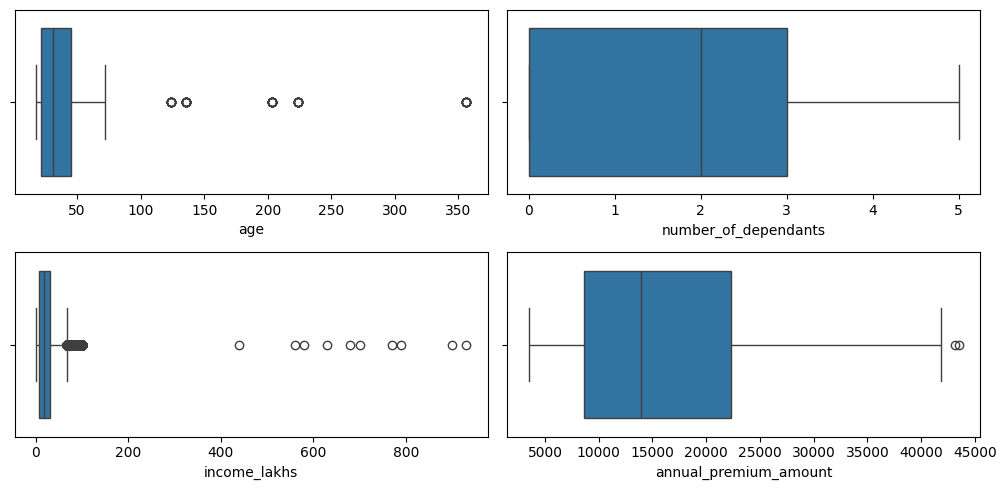

In [75]:
# Plot boxplots for all numerical columns to identify potential outliers visually
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

for i, columns in enumerate(numeric_cols):
    ax = axs.flatten()[i]
    sns.boxplot(x=df[columns], ax=ax)
plt.tight_layout()
plt.show()

In [76]:
# Identify records where age is greater than 100 (likely data entry errors)
df[df.age>100].shape, df[df.age>100].age.unique()

((58, 13), array([224, 124, 136, 203, 356]))

In [77]:
# Filter out records with age > 100
df1 = df[df.age <= 100]
print(f"Shape after removing age outliers: {df1.shape}")
print(df1.age.describe())
df1.head()

Shape after removing age outliers: (49918, 13)
count    49918.000000
mean        34.401839
std         13.681600
min         18.000000
25%         22.000000
50%         31.000000
75%         45.000000
max         72.000000
Name: age, dtype: float64


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [78]:
# Define a function to calculate the Interquartile Range (IQR) bounds for outlier detection
def gte_IQR_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75]) # 25th and 75th percentiles
    IQR = Q3 - Q1 # Interquartile range
    upper = Q3 + 1.5 * IQR # Upper bound
    lower = Q1 - 1.5 * IQR # Lower bound
    return upper, lower

# Calculate upper and lower bounds for 'income_lakhs'
u, l = gte_IQR_bounds(df1.income_lakhs)
print('upper',u)
print('lower',l)

upper 67.0
lower -29.0


In [79]:
# See how many rows exceed the upper bound for income
df1[df1.income_lakhs > u].shape

(3559, 13)

* There are 3,559 records with an `income_lakhs` value above the upper IQR bound (67 lakhs). Therefore, using this bound as an upper limit is not ideal in this situation.

In [80]:
# Instead of strict IQR, let's find the 99.9th percentile to cap extreme high incomes
quantity_threshold_income = df1.income_lakhs.quantile(0.999)
quantity_threshold_income

np.float64(100.0)

In [81]:
# See how many rows exceed this 99.9th percentile threshold
df1[df1.income_lakhs > quantity_threshold_income].shape

(10, 13)

* Only 10 records exceed the 99.9th percentile for `income_lakhs` (100 lakhs). Therefore, using this quantile as an upper limit is more logical than using the IQR upper bound.

In [82]:
# Filter out the top 0.1% extreme income values
df2 = df1[df1.income_lakhs <= quantity_threshold_income].copy()
print(f"Shape after removing income outliers: {df2.shape}")
df2.head()


Shape after removing income outliers: (49908, 13)


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


### Conclusions: Data Cleaning
- We removed missing values and duplicate rows.
- Fixed negative dependent counts (e.g., -2 became 2).
- Removed unrealistic ages (> 100 years).
- Capped extreme incomes at the 99.9th percentile to prevent them from skewing the model.

---
## 4. Exploratory Data Analysis (EDA)
In this section, we will visualize the data to understand the distribution of variables and their relationships with the target variable (`annual_premium_amount`).
- **Univariate Analysis:** Looking at one variable at a time.
- **Bivariate Analysis:** Comparing variables against our target.

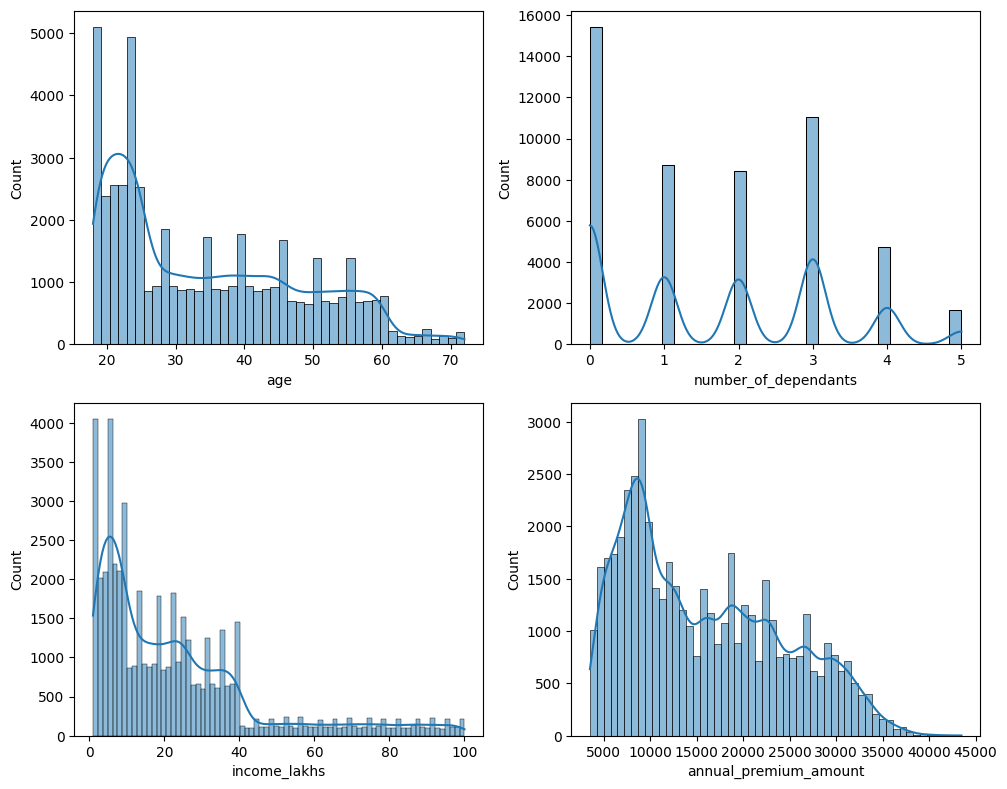

In [83]:
# Plot histograms with KDE (Kernel Density Estimate) for numerical columns
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for i, columns in enumerate(numeric_cols):
    ax = axs.flatten()[i]
    sns.histplot(df2[columns], ax=ax, kde=True)
plt.tight_layout()
plt.show()

In [84]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


### Bivariate Analysis: Numeric Features vs. Premium
Let's see how numeric features like age, dependents, and income correlate with the annual premium amount.

In [85]:
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

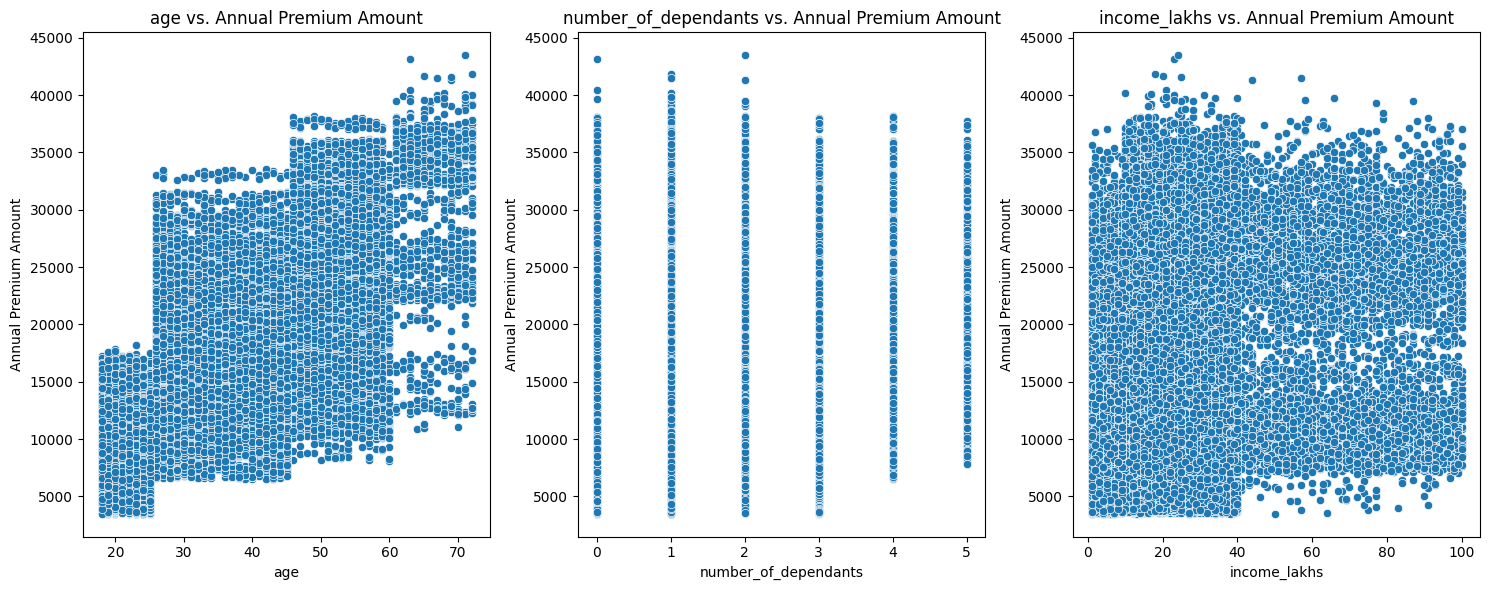

In [86]:
# Create scatter plots to visualize relationships between numeric features and the target variable
numeric_features = ['age', 'number_of_dependants', 'income_lakhs']
fig, axs = plt.subplots(1, len(numeric_features), figsize=(15, 6))

for i, col in enumerate(numeric_features):
    ax = axs[i]
    # Scatter plot of feature vs annual premium
    sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{col} vs. Annual Premium Amount')
    ax.set_xlabel(col)
    ax.set_ylabel('Annual Premium Amount')
plt.tight_layout()
plt.show()


### Categorical Columns Overview
Now let's look at non-numeric (categorical) data.

In [87]:
# Identify all categorical (object type) columns
cat_cols = df2.select_dtypes('object').columns
cat_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [88]:
# Print unique values for each categorical column to see the categories
for col in cat_cols:
    print(f"{col}: {df2[col].unique()}")

gender: ['Male' 'Female']
region: ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
income_level: ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


In [89]:
# Standardize inconsistent entries in 'smoking_status'
df2['smoking_status'] = df2['smoking_status'].replace({
    'Smoking=0':'No Smoking',
    'Does Not Smoke':'No Smoking',
    'Not Smoking':'No Smoking'
})
# Verify the standardized unique values
df2['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

### Univariate Analysis: Categorical Features
Let's look at the percentage distribution of each category.

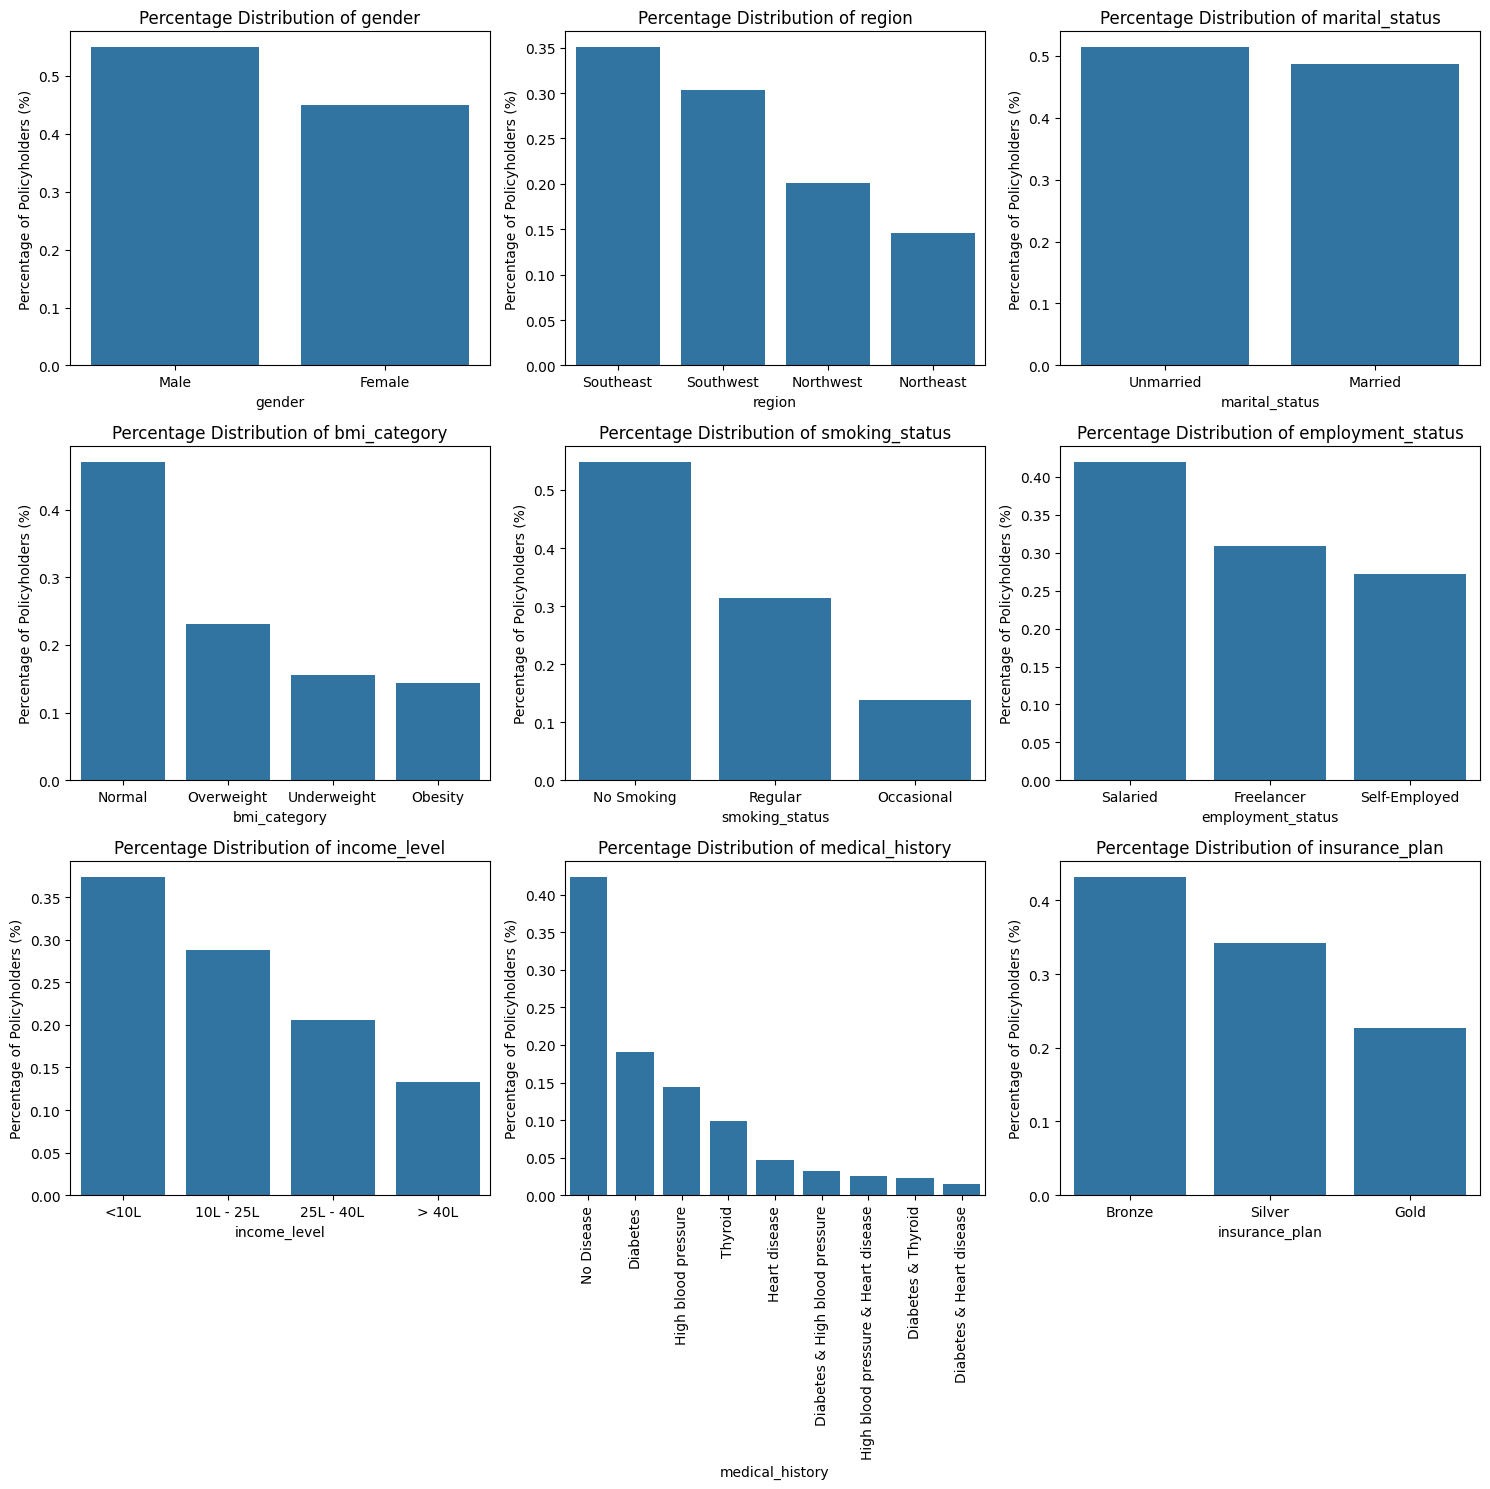

In [90]:
# Create bar charts to show the percentage distribution of each categorical feature
fig, axs = plt.subplots(3, 3, figsize = (15, 15))

for i, col in enumerate(cat_cols):
    ax = axs.flatten()[i]
    # Calculate percentage counts for each category
    pct_count = df2[col].value_counts(normalize=True)

    # Plot a bar chart
    sns.barplot(x=pct_count.index, y=pct_count.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {col}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(col)

    # Rotate x-axis labels if they are long or numerous for readability
    if len(pct_count.index) > 4 or any(len(str(x)) > 20 for x in pct_count.index):
        ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


### Bivariate Analysis: Income Level vs. Insurance Plan
Let's see how different income levels choose their insurance plans.

In [91]:
# Create a cross-tabulation table to count occurrences of each combination (pd.crosstab(2categorical variables ke beech relationship show))
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


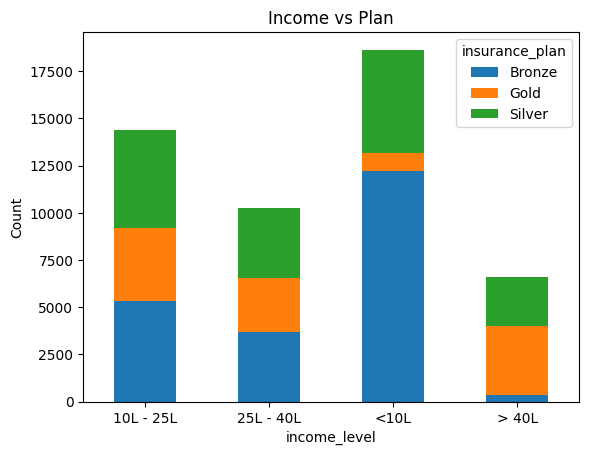

In [92]:
# Visualize the cross-tabulation as a stacked bar chart
crosstab.plot(kind="bar", rot=0, stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

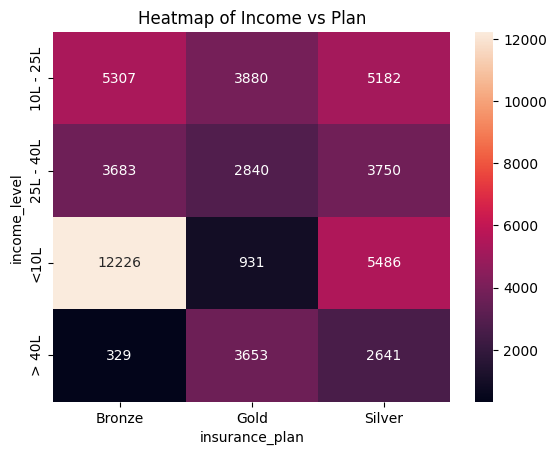

In [93]:
# Visualize the same data as a heatmap for easier pattern spotting
sns.heatmap(data=crosstab, annot=True, fmt="g")
plt.title('Heatmap of Income vs Plan')
plt.show()


**Key Observations**
- Insurance plan choice is strongly correlated with income level.
- Lower income customers gravitate towards affordable plans (Bronze).
- Higher income customers prefer premium plans (Gold).
- The middle-income segment shows mixed preferences, with Bronze and Silver being competitive choices.

_This suggests pricing is the primary driver of plan selection._

### Conclusions: EDA
- **Numeric Features:** Age and Income show positive trends with the Premium Amount (higher age/income loosely relates to higher premiums).
- **Categorical Features:** We cleaned up inconsistent 'smoking_status' labels. Most people choose Bronze or Silver plans.
- **Income vs Plan:** Higher income individuals tend to opt for Gold/Silver plans more often than lower-income individuals.

---
<h2 align="center">5. Feature Engineering</h2>

In this section, we create new features and transform existing ones to make them suitable for machine learning algorithms.
- **Risk Score:** Creating a numerical score based on medical history.
- **Encoding:** Converting text categories into numbers.
- **Scaling:** Scaling numeric values to a standard range.

In [94]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


### Calculating Risk Score
We will extract diseases from the `medical_history` column and assign a risk score to quantify a person's health risk.

In [95]:
# View unique medical history combinations
df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [96]:
# Define a dictionary to assign a risk score to each disease
risk_score = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

# Split the 'medical_history' string (e.g., "Diabetes & Thyroid") into two separate columns
df2[['disease1', 'disease2']] = df2.medical_history.str.split(' & ', expand=True).apply(lambda x: x.str.lower())
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,None


In [97]:
# Fill missing second diseases with 'none'
df2[['disease1', 'disease2']] = df2[['disease1', 'disease2']].fillna('none')
# Initialize a new column for total risk score
df2['total_risk_score'] = 0

# Calculate the total risk score by mapping the diseases to their predefined scores
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_score)

# Normalize the total risk score to be between 0 and 1 using MinMaxScaler
scale = MinMaxScaler()
df2['normalized_risk_score'] = scale.fit_transform(df2[['total_risk_score']])
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571


In [98]:
# Verify the scores for people with two diseases
df2[df2.disease2 != 'none'].head()


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
6,33,Male,Southeast,Married,3,Normal,Regular,Self-Employed,<10L,4,Diabetes & High blood pressure,Silver,20653,diabetes,high blood pressure,12,0.857143
29,18,Female,Northwest,Unmarried,1,Underweight,No Smoking,Salaried,<10L,5,Diabetes & High blood pressure,Bronze,8187,diabetes,high blood pressure,12,0.857143
36,29,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,10L - 25L,11,High blood pressure & Heart disease,Gold,29249,high blood pressure,heart disease,14,1.000000
40,18,Female,Southeast,Unmarried,1,Normal,Occasional,Freelancer,<10L,8,Diabetes & High blood pressure,Bronze,8111,diabetes,high blood pressure,12,0.857143
41,26,Male,Northwest,Married,2,Obesity,Regular,Salaried,10L - 25L,21,Diabetes & Thyroid,Silver,24756,diabetes,thyroid,11,0.785714


### Encoding Text Columns
Machine learning models need numbers, not text. We will map ordinal categories (where order matters, like Bronze < Silver < Gold) to numbers.

In [99]:
# Check unique values in insurance plan
df2.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [100]:
# Map ordinal categories to numerical values
df2['insurance_plan'] = df2['insurance_plan'].map({
    'Bronze':1,
    'Silver':2,
    'Gold': 3
})

df2['income_level'] = df2['income_level'].map({
    '<10L':1,
    '10L - 25L':2,
    '25L - 40L':3,  # Adjusted mapping to be ordinal (1, 2, 3, 4)
    '> 40L':4
})

# Verify the mappings
df2['insurance_plan'].unique(), df2['income_level'].unique()

(array([1, 2, 3]), array([1, 2, 4, 3]))

In [101]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,diabetes,none,6,0.428571


In [102]:
# For nominal categories (where order doesn't matter, like gender or region), use One-Hot Encoding
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
pd.set_option('display.max_columns', None) # Show all columns in display
# get_dummies converts categorical variables into dummy/indicator variables (0 or 1)
# drop_first=True helps avoid the dummy variable trap (multicollinearity)
df3 = pd.get_dummies(data=df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


### Feature Selection
Dropping raw text columns that we have already processed into numbers.

In [103]:
# Drop original medical history columns and the raw total risk score (keeping the normalized one)
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1


### Multicollinearity Check (VIF)
We check if independent variables are highly correlated with each other using a correlation matrix and Variance Inflation Factor (VIF). High VIF means features are too similar.

In [104]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

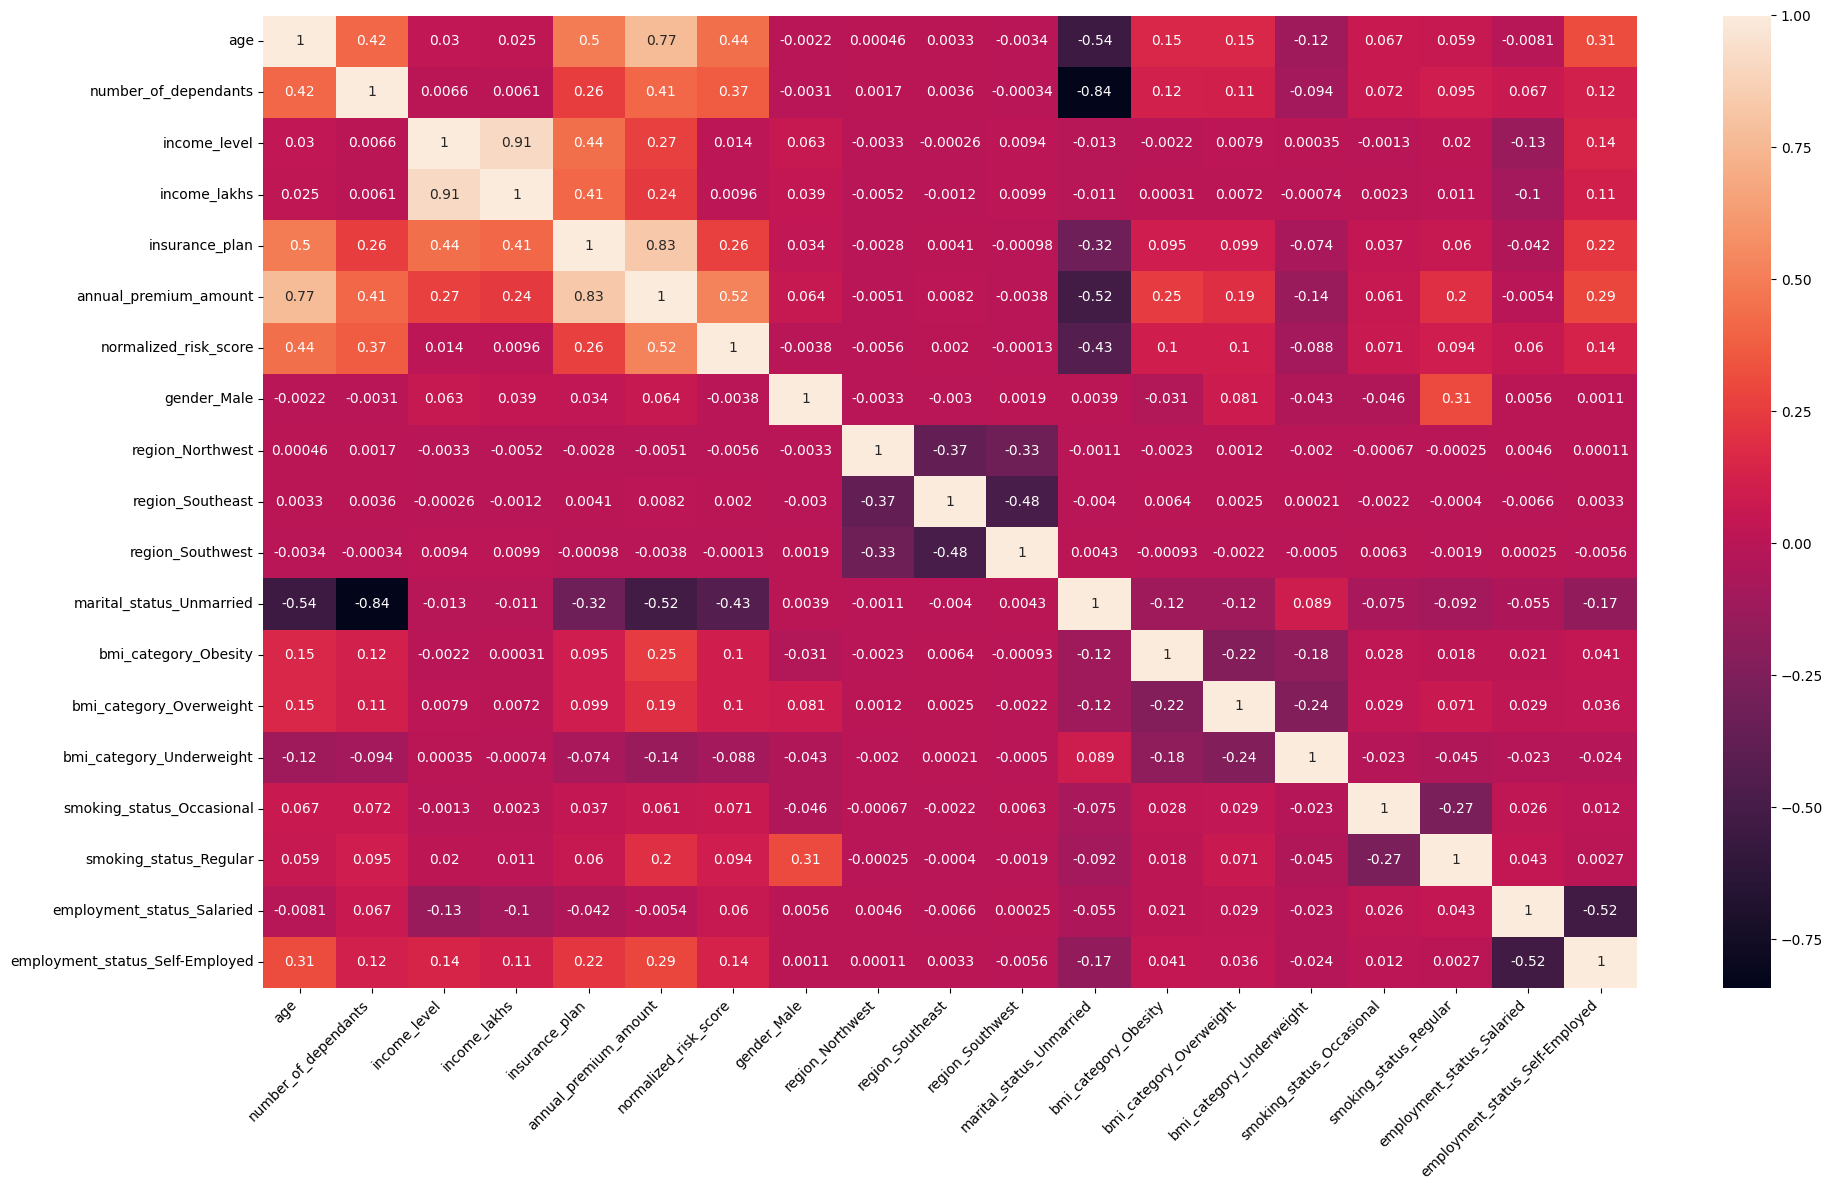

In [105]:
# Calculate correlation matrix
cm = df4.corr()
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [106]:
# Separate features (X) and target variable (y)
X = df4.drop('annual_premium_amount', axis=1)
y = df4['annual_premium_amount']

# Scale continuous numerical columns so they are on a similar scale (0 to 1)
cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
X[cols_to_scale] = scale.fit_transform(X[cols_to_scale])

In [107]:
# Verify scaling
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [108]:
# Import VIF calculator
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define function to calculate VIF for all features
def calculate_vif(data):
        vif_df = pd.DataFrame()
        vif_df['Column'] = data.columns
        vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
        return vif_df

In [109]:
# Display VIF scores
calculate_vif(X)


,Column,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalized_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


* Features such as `income_level` and `income_lakhs` have a VIF greater than 10, indicating high multicollinearity. This means these features are strongly correlated with other independent variables in the dataset, which can make the model's coefficients unstable and harder to interpret.

In [110]:
X.drop('income_level', axis=1, inplace=True)

In [111]:
# Display VIF scores after dropping
calculate_vif(X)

,Column,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


* Removing `income_level` brought the VIF of all features below 5, suggesting that it was the primary source of multicollinearity in the dataset. The remaining features are now sufficiently independent for reliable model building.

### Conclusions: Feature Engineering
- **Risk Score:** Converted text-based disease history into a normalized numerical risk score.
- **Encoding:** Successfully converted all text categories into numerical format (Ordinal and One-Hot Encoding).
- **VIF Check:** Features look mostly fine, ready for modeling.

---
<h2 align="center" style="color:blue">6. Model Training & Evaluation</h2>

We will split our data into training (to teach the model) and testing (to evaluate it) sets. We will test three models:
1. Linear Regression
2. Ridge Regression
3. XGBoost Regressor

In [112]:
# Split data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print('X Train', X_train.shape)
print('Y Train', y_train.shape[0])
print('X Test', X_test.shape)
print('Y Test', y_test.shape[0])

X Train (34935, 17)
Y Train 34935
X Test (14973, 17)
Y Test 14973


### 6.1 Linear Regression
A simple baseline model that draws a straight line through the data.

In [113]:
import numpy as np
# Initialize and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Calculate R-squared scores
test_Score = model.score(X_test, y_test)
train_Score = model.score(X_train, y_train)

# Predict on test data
pred_y = model.predict(X_test)

# Calculate errors “R-squared shows how well the model explains the data, while RMSE gives the average prediction error.”
mse = mean_squared_error(y_test, pred_y)
rmse = np.sqrt(mse)

print("Test Score Of Linear Regression:",test_Score)
print("Train Score Of Linear Regression:",train_Score)
print("MSE:",mse)
print("RMSE:",rmse)

Test Score Of Linear Regression: 0.9283765993531428
Train Score Of Linear Regression: 0.9280957176093705
MSE: 5056639.130347775
RMSE: 2248.6972073509087


In [114]:
# Extract and format feature coefficients (importance)
features_importance = model.coef_
coef_df = pd.DataFrame(data=features_importance, index=X_train.columns, columns=['Coefficients'])
# Sort to see most negatively and positively impactful features
coef_df.sort_values(by='Coefficients', ascending=True, inplace=True)
coef_df

,Coefficients
marital_status_Unmarried,-821.780886
number_of_dependants,-536.611730
income_lakhs,-353.970671
region_Northwest,-34.502191
region_Southwest,-23.473726
region_Southeast,27.975046
gender_Male,121.530230
employment_status_Salaried,149.571795
bmi_category_Underweight,364.313509
employment_status_Self-Employed,378.251303


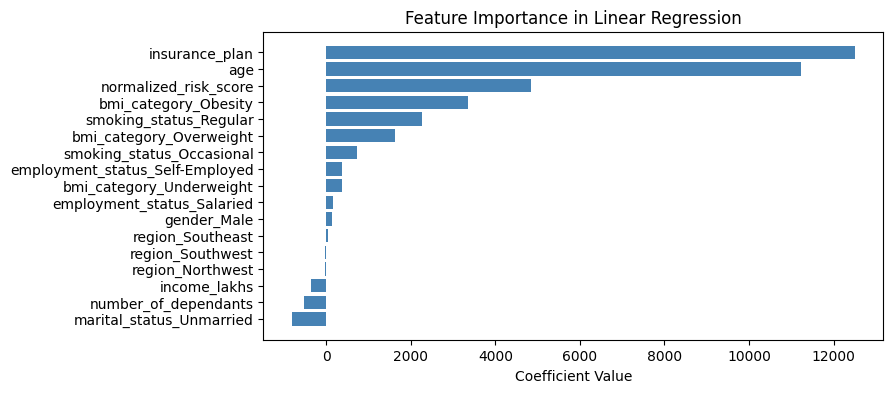

In [115]:
# Visualize feature importance for Linear Regression
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

* The coefficients from the Linear Regression Model reveal that `insurance_plan` and `age` have the highest values, indicating that these features have the strongest influence on the target variable [`annual_premium_amount`]. A unit increase in age / insurance_plan leads to the greatest change in the predicted output compared to other features.

### 6.2 Ridge Regression
Similar to Linear Regression, but applies a penalty to prevent overfitting.

In [116]:
# Initialize and train Ridge Regression model
model = Ridge(alpha=1)
model.fit(X_train, y_train)

# Calculate R-squared scores
test_Score = model.score(X_test, y_test)
train_Score = model.score(X_train, y_train)

# Predict on test data
pred_y = model.predict(X_test)

# Calculate errors
mse = mean_squared_error(y_test, pred_y)
rmse = np.sqrt(mse)

print("Test Score Of Ridge Regression:",test_Score)
print("Train Score Of Ridge Regression:",train_Score)
print("MSE:",mse)
print("RMSE:",rmse)

Test Score Of Ridge Regression: 0.9283764905001946
Train Score Of Ridge Regression: 0.9280956798900619
MSE: 5056646.815407016
RMSE: 2248.698916130618


### 6.3 XGBoost Regression
A powerful tree-based ensemble method that often captures non-linear relationships well.

In [117]:
# Initialize and train a basic XGBoost model
model = XGBRegressor(n_estimators=20, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Calculate R-squared scores
test_Score = model.score(X_test, y_test)
train_Score = model.score(X_train, y_train)

# Predict on test data
pred_y = model.predict(X_test)

# Calculate errors
mse = mean_squared_error(y_test, pred_y)
rmse = np.sqrt(mse)

print("Test Score Of XGBoost Regression:",test_Score)
print("Train Score Of XGBoost Regression:",train_Score)
print("MSE:",mse)
print("RMSE:",rmse)

Test Score Of XGBoost Regression: 0.9781450033187866
Train Score Of XGBoost Regression: 0.9783400893211365
MSE: 1542969.5
RMSE: 1242.1632340397134


### 6.4 XGBoost Hyperparameter Tuning
We will use RandomizedSearchCV to find the best settings (hyperparameters) for our XGBoost model to improve its performance.

In [118]:
model = XGBRegressor()
# Define a grid of parameters to try
pera_grid = {
    'n_estimators':[20, 40, 50],
    'learning_rate':[0.01, 0.1, 0.2],
    'max_depth':[3, 4, 5]
}

# Randomly search through the grid, testing 10 different combinations with 3-fold cross validation
rendom_search = RandomizedSearchCV(model, pera_grid, cv=3, n_iter=10, scoring='r2', n_jobs=1, random_state=42)
rendom_search.fit(X_train, y_train)

# Display the best cross-validated R2 score found
print(f"Best CV Score: {rendom_search.best_score_}")

Best CV Score: 0.9810737768809


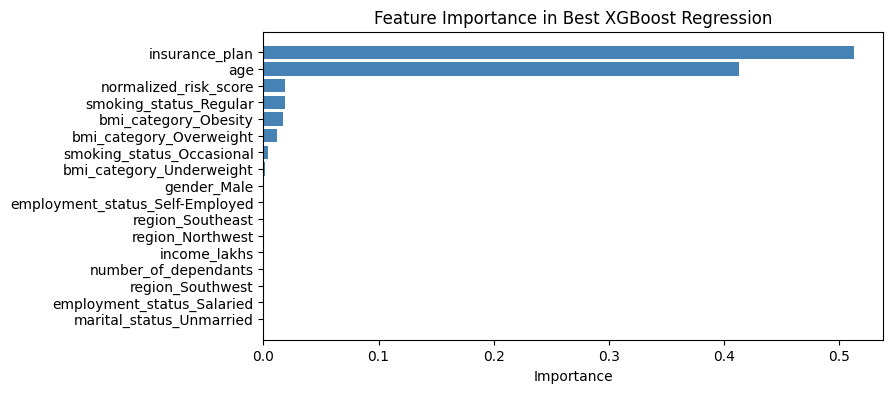

In [119]:
# Get the best model found during the search
best_model = rendom_search.best_estimator_

# Extract and plot feature importances from the best XGBoost model
features_importance = best_model.feature_importances_
coef_df = pd.DataFrame(data=features_importance, index=X_train.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients', ascending=True, inplace=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance in Best XGBoost Regression')
plt.show()


* The coefficients from the Best XGBoost Regression Model reveal that `age` and `insurance_plan` have the highest values, indicating that these features have the strongest influence on the target variable. Same as the Linear Regression Model

### Conclusions: Modeling
- Linear Regression and Ridge Regression perform similarly, indicating a linear baseline.
- XGBoost generally captures more complex patterns. The Feature Importance chart highlights which factors (like age or specific health risks) impact the premium the most in the XGBoost model.

---
## 7. Error Analysis
We need to understand where our model is making mistakes. Are we overpredicting or underpredicting? By how much? We will look specifically at "extreme errors" where our prediction is off by more than 10%.

In [120]:
# Predict using the best tuned XGBoost model
pred_y = best_model.predict(X_test)

# Calculate raw differences and percentage differences
residuals = pred_y - y_test
residuals_ptc = ( residuals / y_test ) * 100

# Create a dataframe to compare actuals, predictions, and errors
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': pred_y,
    'diff': residuals,
    'diff_ptc': residuals_ptc
})
results_df.head()

,actual,predicted,diff,diff_ptc
24098,9246,9547.453125,301.453125,3.260363
201,11664,13488.259766,1824.259766,15.640087
25471,10472,7417.219727,-3054.780273,-29.170935
32500,26267,25508.873047,-758.126953,-2.886233
30832,9106,9547.453125,441.453125,4.847937


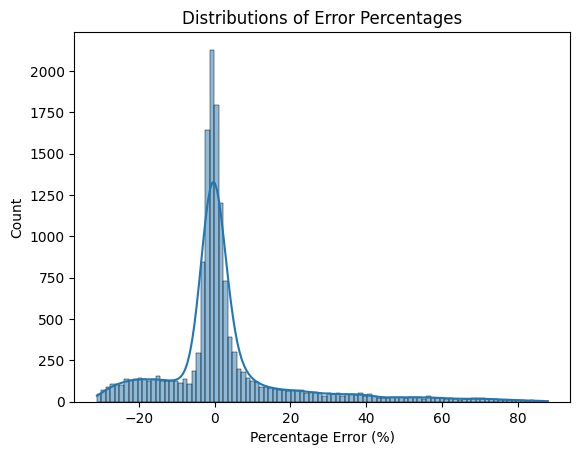

In [121]:
# Plot the distribution of percentage errors
sns.histplot(results_df['diff_ptc'], bins=100, kde=True)
plt.title("Distributions of Error Percentages")
plt.xlabel("Percentage Error (%)")
plt.show()

* The error distribution reveals that most predicted values deviate by ±10% from the actual values. While this may seem small, in the context of annual premium prediction, even a 10% error can translate to a significant monetary difference potentially misleading customers or mispricing insurance plans.

In [122]:
# Define a threshold for "extreme" errors (e.g., > 10% off)
extreme_error_threshold = 10
extreme_result_df = results_df[results_df.diff_ptc > extreme_error_threshold]
print("Shape:",extreme_result_df.shape)
extreme_result_df.head()

Shape: (2378, 4)


,actual,predicted,diff,diff_ptc
201,11664,13488.259766,1824.259766,15.640087
47939,11996,13450.725586,1454.725586,12.126755
26239,4436,6649.229492,2213.229492,49.892459
16907,8952,10888.099609,1936.099609,21.627565
16861,5923,6544.921875,621.921875,10.500116


In [123]:
# Calculate what percentage of our test set has an extreme error
extreme_errors_pct = extreme_result_df.shape[0] * 100 / X_test.shape[0]
print(f"Percentage of extreme errors (>10%): {extreme_errors_pct:.2f}%")

Percentage of extreme errors (>10%): 15.88%


**Observation:** We have about ~15% extreme errors, which means for these customers we will either overcharge or undercharge by 10% or more.

In [124]:
# Check for severely extreme errors (>50% off)
severe_errors = extreme_result_df[abs(extreme_result_df.diff_ptc) > 50].shape[0]
print(f"Number of severe errors (>50%): {severe_errors}")

Number of severe errors (>50%): 533


**Observation:** There are a significant number of customers whom we might overcharge or undercharge by more than 50%.

In [125]:
# Get the feature data specifically for the extreme error cases to see if they share common traits
extreme_error_df = X_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
201,0.129630,0.2,0.636364,1.0,0.0,0,1,0,0,1,0,0,0,0,0,0,0
47939,0.111111,0.0,0.424242,1.0,0.0,0,1,0,0,1,0,0,1,0,0,1,0
26239,0.037037,0.0,0.292929,0.0,0.0,1,1,0,0,1,0,0,1,0,0,0,0
16907,0.111111,0.0,0.606061,0.5,0.0,1,0,0,0,1,0,0,1,0,1,0,0
16861,0.055556,0.0,0.222222,0.0,0.0,1,1,0,0,1,0,0,0,0,0,1,0


In [126]:
# Check number of columns to set up plots
len(X_test.columns)

17

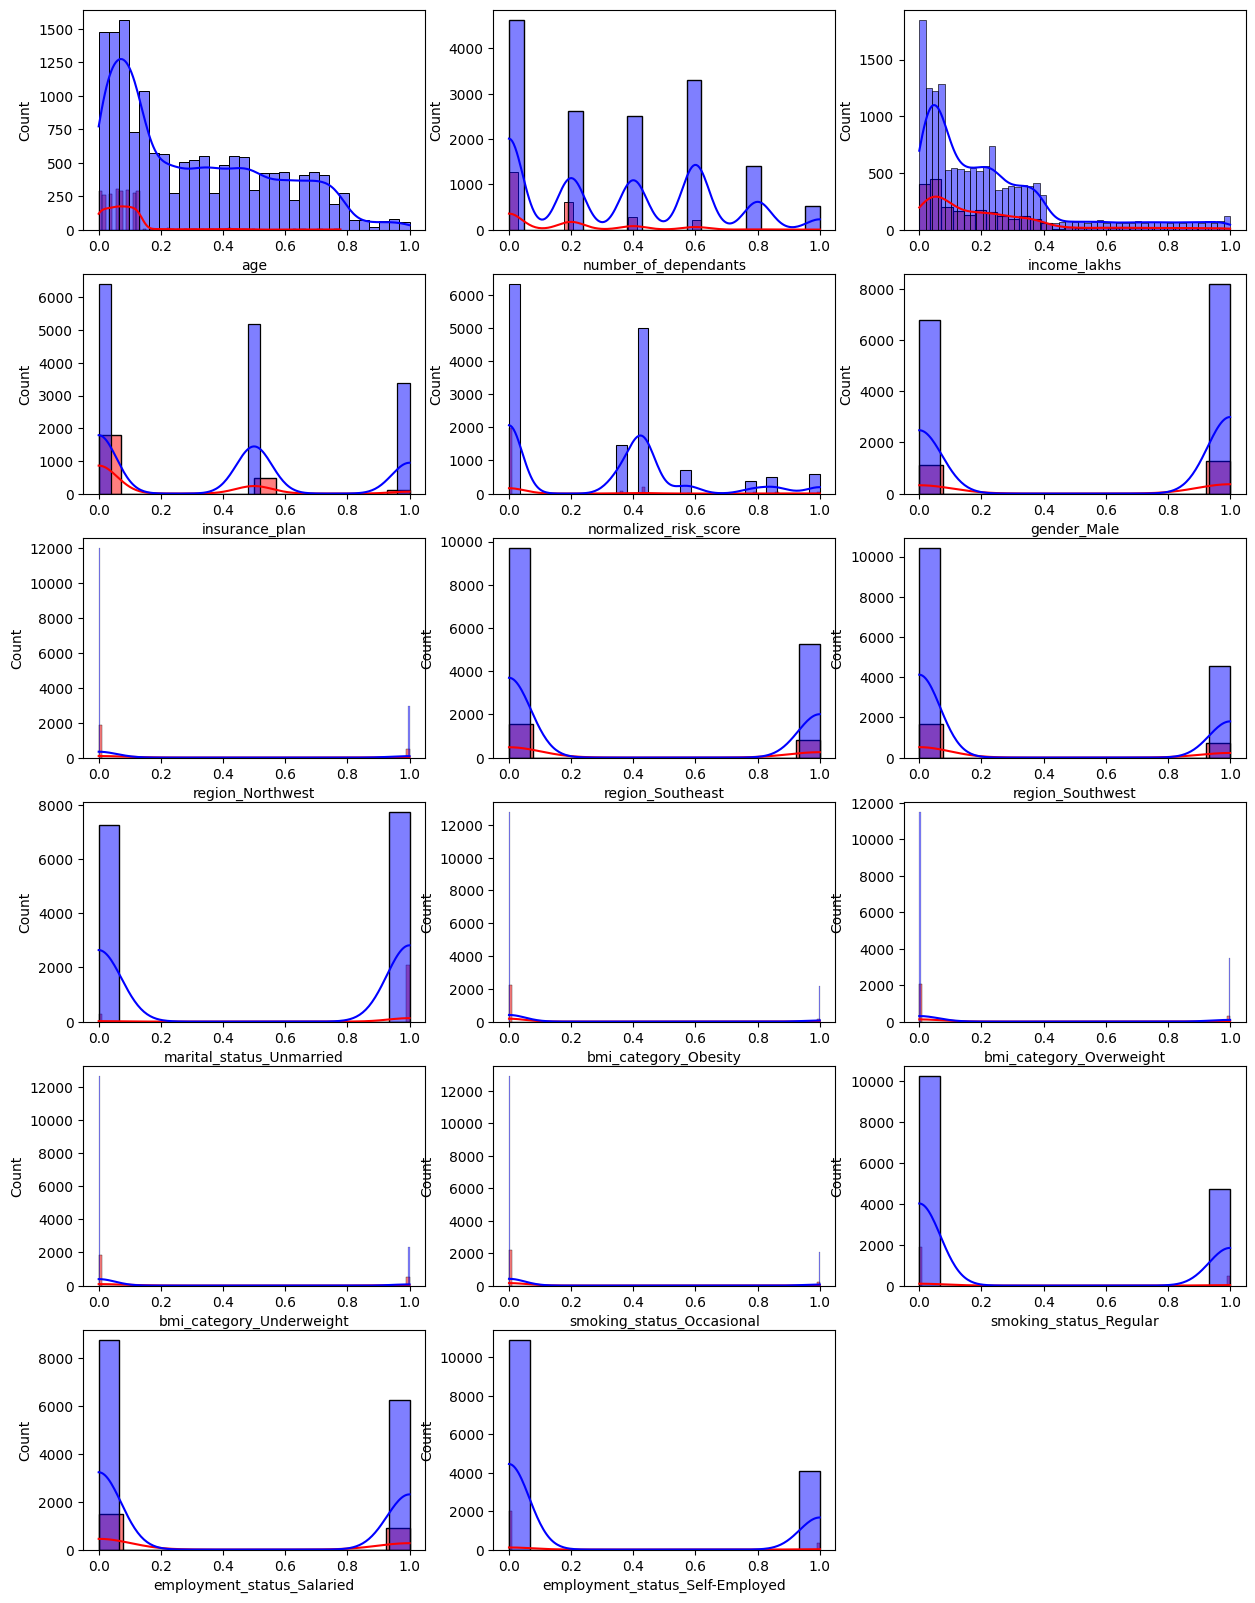

In [127]:
# Compare the distribution of features in the "Extreme Error" group vs the "Overall" dataset
# This helps identify if errors happen more often for specific ages, incomes, etc.
fig, axs = plt.subplots(6, 3, figsize=(15, 20))
for i, col in enumerate(X_test.columns):
    ax = axs.flatten()[i]
    sns.histplot(extreme_error_df[col], color='red', ax=ax, label='Extreme Errors', kde=True)
    sns.histplot(X_test[col], color='blue', ax=ax, label='Overall',kde=True)
axs.flatten()[-1].set_visible(False)
plt.show()

### Reverse Scaling
To interpret our error analysis in human-readable numbers (like actual age rather than a scaled 0-1 value), we reverse the scaling process.

In [128]:
reversed_df = pd.DataFrame()
extreme_error_df['income_level'] = 0
reversed_df[cols_to_scale] = scale.inverse_transform(extreme_error_df[cols_to_scale])
reversed_df.drop('income_level', axis=1, inplace=True)
reversed_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan
0,25.0,1.0,64.0,3.0
1,24.0,0.0,43.0,3.0
2,20.0,0.0,30.0,1.0
3,24.0,0.0,61.0,2.0
4,21.0,0.0,23.0,1.0


In [129]:
# View summary statistics of the unscaled extreme error features
reversed_df.describe()

,age,number_of_dependants,income_lakhs,insurance_plan
count,2378.000000,2378.000000,2378.000000,2378.000000
mean,22.229184,0.772918,21.211943,1.303616
std,4.292625,1.002600,20.698684,0.560511
min,18.000000,0.000000,1.000000,1.000000
25%,20.000000,0.000000,6.000000,1.000000
50%,22.000000,0.000000,15.000000,1.000000
75%,24.000000,1.000000,30.000000,2.000000
max,60.000000,5.000000,100.000000,3.000000


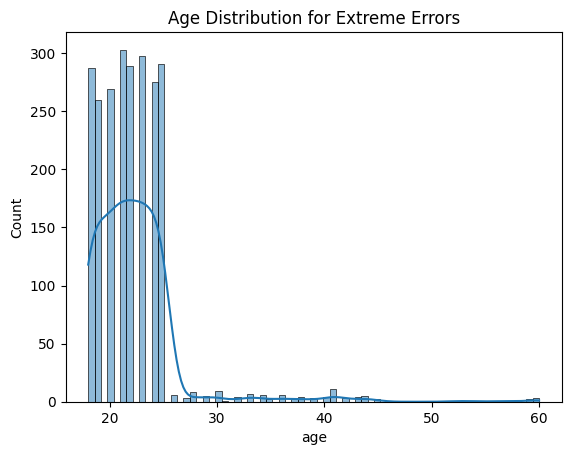

In [130]:
# Look at the unscaled age distribution for extreme errors
sns.histplot(reversed_df['age'], kde=True)
plt.title("Age Distribution for Extreme Errors")
plt.show()

* The distribution is heavily right-skewed, with the vast majority of extreme prediction errors concentrated in customers aged 18–25. The error count drops sharply after age 25 and becomes nearly negligible beyond age 30
* The model struggles significantly with young customers (18–25 years), producing the most extreme prediction errors in this age group. This could be because young customers may have more varied or unpredictable premium amounts that the model hasn't learned well. Older customers (30+) are predicted with much higher accuracy, suggesting the model is better trained on that demographic

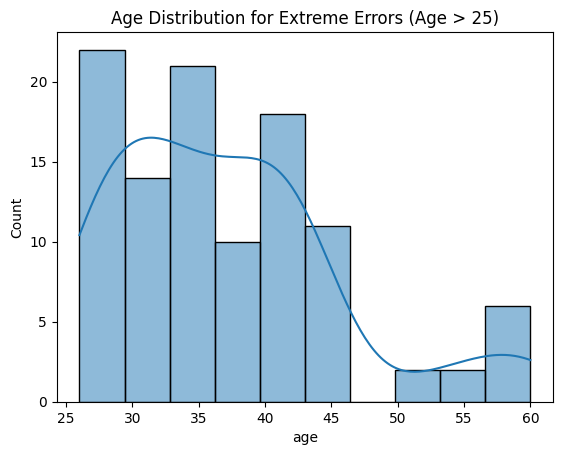

In [132]:
# Look closely at older individuals (>25) in the extreme error group
sns.histplot(reversed_df[reversed_df['age'] > 25]['age'], bins=10, kde=True)
plt.title("Age Distribution for Extreme Errors (Age > 25)")
plt.show()


---
## 8. Final Conclusions & Summary

1. **Data Overview & Preprocessing:** The dataset required moderate cleaning, primarily handling outliers in `age` and capping extreme `income` to prevent model skewing. We mapped textual health data to a numerical `risk_score`.
2. **Modeling:** Tree-based models (XGBoost) perform well on this data, capturing non-linear relationships better than basic Linear Regression.
3. **Important Features:** Based on feature importance, factors like age, specific health risks, and insurance plan tier heavily influence the premium amount.
4. **Error Analysis** — Where the Model Struggles
    - While the model performs reasonably well overall, a deeper error analysis reveals some important limitations worth addressing.
    - Approximately 15% of predictions deviate by more than 10% from the actual premium amount — which in the context of insurance pricing, can translate to a meaningful monetary difference for both the customer and the provider.
    - A closer look at the extreme error distribution shows that young customers aged 18–25 are disproportionately responsible for these large errors. Despite appearing balanced in the overall distribution, this age group consistently produces the highest prediction errors — suggesting the model has not learned this demographic well enough, possibly due to higher variability in their premium amounts or underrepresentation in training data.
    - To address this, future improvements should focus on:

        - Collecting more training samples for younger age groups
        - Engineering age-specific interaction features (e.g., age × risk score, age × smoking status)
        - Exploring model segmentation — training a separate model specifically for customers under 25